# Graph classification: what can GIN distinguish?

Tier B · three live TODOs. Author evidence is labeled separately. The default live run is a short demonstration; the complete paper search is explicitly available below.

In [1]:
# Complete inline implementation; no private module or repository checkout required.
import sys, subprocess
if 'google.colab' in sys.modules:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--index-url', 'https://download.pytorch.org/whl/cpu', 'torch==2.13.0+cpu'])
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'numpy==2.5.0', 'scikit-learn==1.9.0', 'scipy==1.18.0'])
import importlib.metadata as metadata
print({n: metadata.version(n) for n in ['torch','numpy','scikit-learn']})


{'torch': '2.13.0+cpu', 'numpy': '2.5.0', 'scikit-learn': '1.9.0'}


## Start with retrieval

Write the three retrieval answers below before reading.

Before reading, write three answers from memory: What makes a message-passing layer invariant to the order of a node's neighbors? What does the `batch` vector identify in a disjoint union? Why can a validation score used to select a model be optimistic?

**Your tangible win.** Implement a GIN update and whole-graph readout, then explain a pair of graphs the model cannot separate. The core reading takes about 25 minutes. The notebook adds three live implementation tasks; the full reproduction is a separate, much longer run.

[Lesson 87](https://avistian.github.io/relational/lessons/0087-link-prediction.html) ended by turning a candidate link into an enclosing subgraph. Now the prediction target is the entire graph. One molecule yields one class label, even though molecules have different numbers of atoms. Our mission needs this step: relational models must compress variable-size neighborhoods without silently discarding the distinctions a task needs.



## 1 · From node rows to one graph prediction

> **In plain terms.** A graph classifier must ignore how we number the nodes while preserving the information that distinguishes graphs.

A graph is a set of nodes and their edges. A node feature is a vector describing a node. **Graph classification** assigns one category to each graph; it is different from assigning a category to each node. In MUTAG, nodes represent atoms, the input provides categorical atom tags, and the binary target describes a molecular mutagenicity assay. The released GIN input does not use bond labels. Read the dataset description in [Xu et al., Appendix I](https://arxiv.org/html/1810.00826v3#A9).

A **readout** reduces all node representations of one graph to a fixed-length vector. If node representations have width *d*, sum, mean, and coordinate-wise maximum each return *d* numbers, regardless of graph size. A final classifier maps those numbers to class scores, called **logits**. Softmax converts logits into probabilities; cross-entropy trains the correct class to receive higher probability.

**Two different reductions.** Neighbor aggregation combines adjacent nodes to update one node. Graph readout combines all nodes to predict one graph. Changing graph readout does not change the neighbor aggregator. The experiment later changes readout only.

In a mini-batch, we concatenate node rows from several graphs and offset their edge indices. The `batch` vector records which graph owns each row. Edges never cross graph boundaries. `graph_readout(h, batch, B)` returns a `[B, d]` matrix for *B* graphs. A sum over every row without grouping would merge unrelated molecules.



## 2 · Counting is information

**Predict first.** Duplicate every node representation in a readout input. Which reduction must retain that change when the sum is nonzero?

Predict: sum, mean or max? Commit before reading the worked example.

**Worked example.** Encode atom type A as `[1,0]` and type B as `[0,1]`. The multiset `{A,A,B}` has sum `[2,1]`; `{A,A,A,A,B,B}` has sum `[4,2]`. A **multiset** retains repetition. A set would retain only which distinct types occur.

<figure class="mpnn-figure"><div class="figure-scroll" tabindex="0">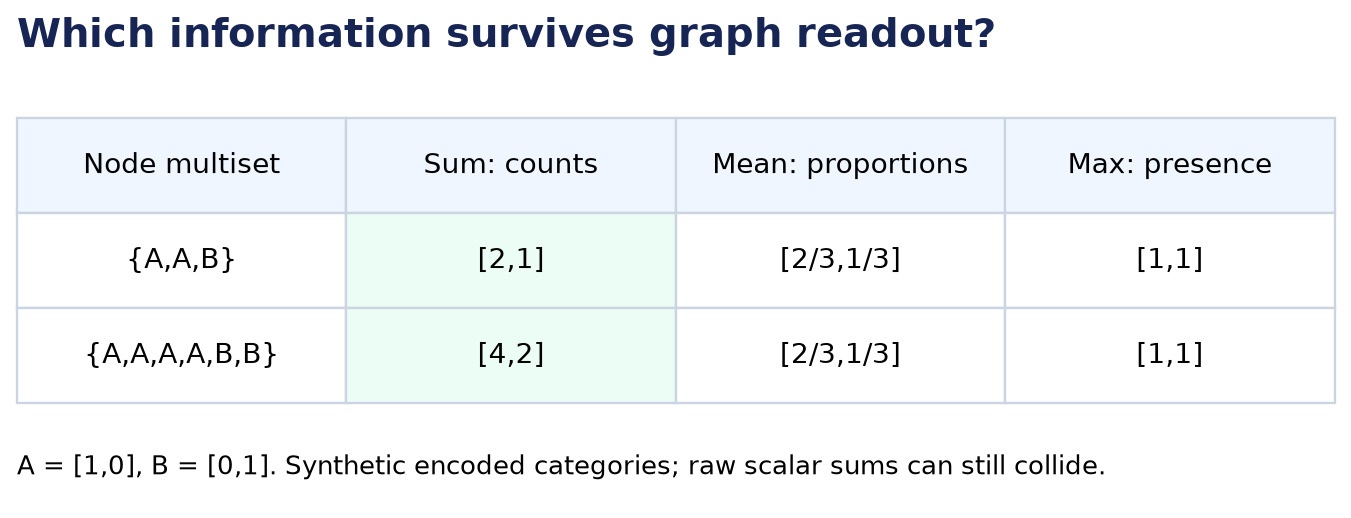</div><figcaption>Synthetic categorical encodings expose counts, proportions and presence.</figcaption></figure>

Mean divides by the number of rows. Both multisets become `[2/3,1/3]`, so this representation describes proportions and loses total multiplicity. Coordinate-wise max returns `[1,1]` for both, describing presence. These collisions cannot be repaired by a classifier that sees only the collided vector. But mean can be a useful inductive bias when size should not matter. Greater expressive capacity is not a guarantee of better generalization.

**Sum is not magically injective.** An **injective** function maps distinct inputs to distinct outputs. Raw scalar sums collide too: `{1,3}` and `{2,2}` both sum to 4. The paper's result concerns sums of suitable encodings of elements from a countable domain with bounded multiset size. It establishes that an injective encoding exists; it does not prove arbitrary features or learned finite-width networks never collide. See [Lemma 5 and Corollary 6](https://arxiv.org/html/1810.00826v3#S4.SS1).



## 3 · WL: refine colors, then compare counts

> **In plain terms.** Two nodes should keep the same structural description only while their own descriptions and their neighborhoods remain indistinguishable.

The **one-dimensional Weisfeiler–Lehman test**, abbreviated **1-WL**, starts with node labels, represented here by colors. One round builds a signature for each node: its current color and the sorted multiset of neighbor colors. Each distinct signature gets a distinct new color. All nodes update simultaneously from the previous round. When comparing graphs, they must share the signature-to-color dictionary; independent arbitrary color numbers cannot be compared.

Count each color within each graph after every round. Different color histograms certify that the graphs are not isomorphic. **Isomorphic** means equal after a relabeling of nodes that preserves edges and initial labels. Equal histograms are inconclusive: WL is not a complete graph-isomorphism test. See [§2 and Theorem 3](https://arxiv.org/html/1810.00826v3#S3).

**Worked example.** Give every node the same initial color. A four-node path has degrees `[1,2,2,1]`; a four-node star has degrees `[3,1,1,1]`. The first WL round encodes these different neighborhood counts, so the graph histograms separate immediately. With identical scalar features, neighbor means would instead give 1 wherever a neighbor exists.

Trace one joint WL round on path/star. Then prove why cycle/triangles cannot separate.

<figure class="mpnn-figure"><div class="figure-scroll" tabindex="0">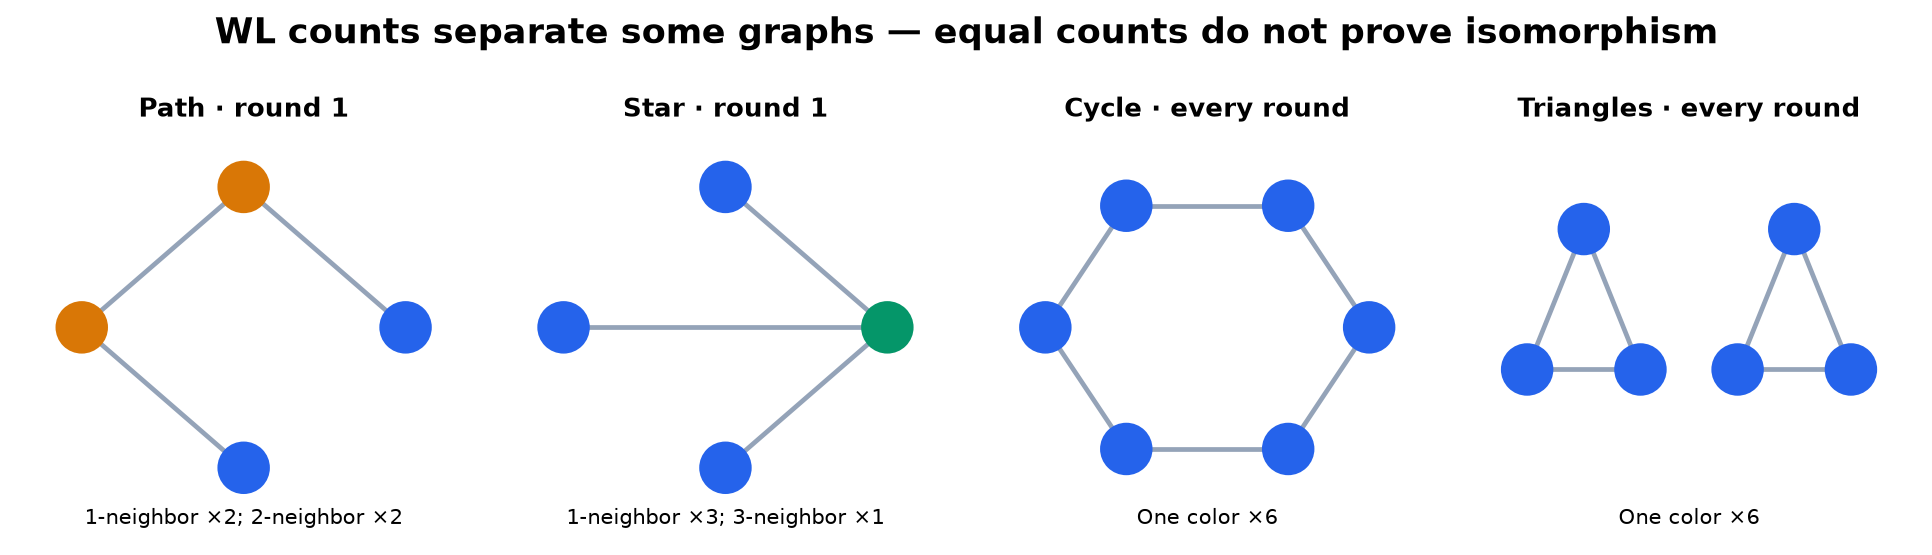</div><figcaption>With identical initial labels, path/star separate in one round; cycle/triangles remain indistinguishable.</figcaption></figure>

**A permanent collision.** Compare a six-cycle with two disjoint triangles. Both have six nodes, every node has two neighbors, and all initial labels match. Every node therefore receives the same signature within each round, in both graphs, forever. A standard message-passing GNN with the same initial features cannot separate them either. Giving nodes informative extra features or using a stronger architecture changes the problem; extra depth alone does not.



## 4 · Model architecture: GIN turns multiset counts into learned features

The **Graph Isomorphism Network (GIN)** uses a sum and a multilayer perceptron, or **MLP**, to learn a neighborhood update. An MLP composes affine maps with nonlinear functions. The nonlinear transformation is needed because one linear map cannot represent every useful multiset distinction. The precise argument and architecture appear in [§4–5 of the primary paper](https://arxiv.org/html/1810.00826v3#S4).

For node *v* at depth *k*:

```text
h_v^(k) = MLP_k((1 + ε_k) h_v^(k−1) + Σ_{u in N(v)} h_u^(k−1))
```

Here `h` is a node vector, `N(v)` is the set of its neighbors, and `ε` weights the center relative to those neighbors. Every node at a given depth uses the same MLP; different depths have separate parameters. **GIN-ε** learns epsilon. **GIN-0**, our paper target, fixes it to zero. At zero, center and neighbors have equal weight. GIN-0 is a practical variant: do not transfer every sufficient injectivity condition for the center–multiset pair to it automatically.

**Worked example.** A center `[1,0]` receives neighbors `[1,0]` and `[0,1]`. Their sum is `[1,1]`; adding the center produces `[2,1]`. This `[2,1]`, not the mean `[2/3,1/3]`, enters the MLP. With epsilon .5 the input would be `[2.5,1]`.

<figure class="mpnn-figure"><div class="figure-scroll" tabindex="0">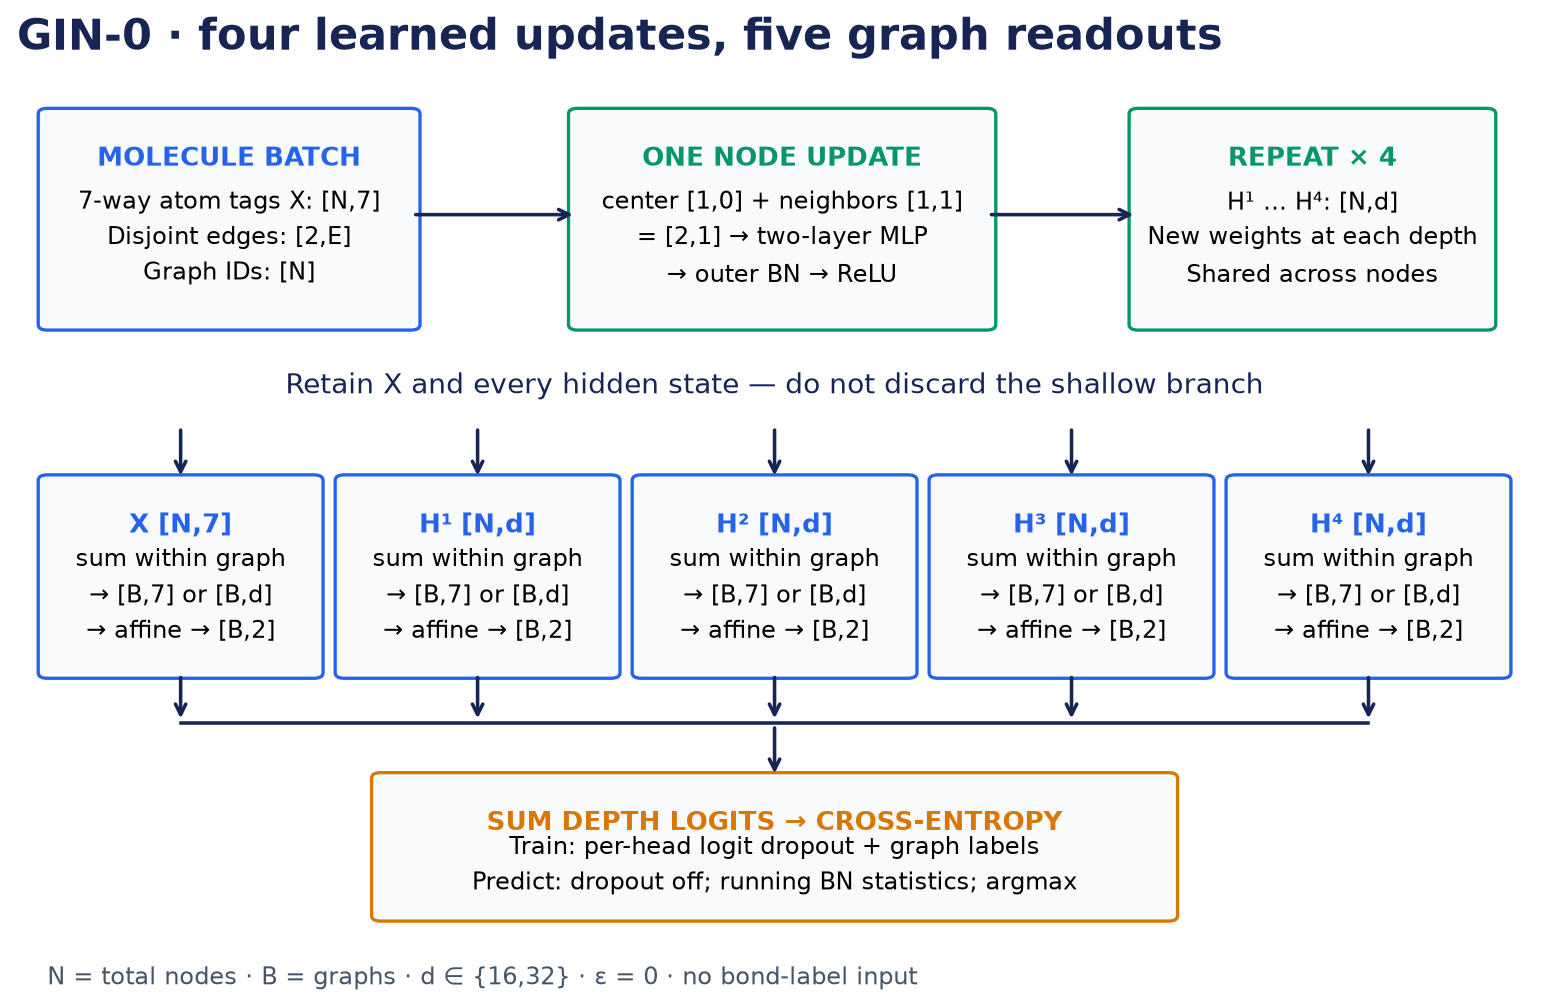</div><figcaption>Complete released GIN-0 path: four node updates, five graph readouts, per-depth heads, logit dropout and graph loss.</figcaption></figure>

The released model contains **four message-passing updates plus the input representation**, described as five layers in the paper. Each update uses a two-layer MLP: linear → batch normalization → ReLU → linear, followed by another batch normalization and ReLU. **Batch normalization** standardizes hidden coordinates using training mini-batch statistics and maintains running statistics for evaluation. **ReLU** keeps positive values and replaces negative values with zero.

GIN keeps information from every depth. It sums node representations separately at depths 0 through 4. The paper describes concatenating these five graph vectors. The release applies a separate affine classification head to each and adds the resulting logits. Without dropout these are equivalent to a single affine map on the concatenation: partition that map by depth and sum its bias terms.

**Release detail.** During training, the code drops individual class logits independently at each depth before summing them. This is not dropout on node embeddings. The dropout rate is tuned over `{0,.5}`. At inference dropout is off and batch normalization uses stored statistics. The same trained weights serve new graphs; graph labels never enter the forward pass. [Pinned model source](https://github.com/weihua916/powerful-gnns/blob/9a2ce8ac3e99278307093a464a95caf0fb04b602/models/graphcnn.py).

```python
# The notebook exposes the complete model, not just this fragment.
h = neighbor_sum(h, edges) + (1 + eps) * h
h = relu(outer_batch_norm(mlp(h)))
pooled = graph_readout(h, batch, num_graphs, mode="sum")
# Repeat at each depth; include the input-depth prediction head.
```

**Capacity, not certainty.** Under injective aggregation and readout conditions, a sufficiently expressive GNN can match the distinctions 1-WL makes. Ordinary message-passing GNNs cannot exceed that bound under matching initial labels. Training may learn less discriminative functions. Neither the theorem nor a training accuracy proves better performance on new molecules.



## 5 · Reproduce a named published experiment

**Target:** Xu et al. (2019), Table 1, MUTAG, Sum–MLP (GIN-0): **89.4 ± 5.6%**. This is one specific cell, not all nine datasets or all model families. Primary reading: [paper §7 and Table 1](https://arxiv.org/html/1810.00826v3#S7). The [authors' README](https://github.com/weihua916/powerful-gnns/tree/9a2ce8ac3e99278307093a464a95caf0fb04b602#cross-validation-strategy-in-the-paper) clarifies the selection procedure.

| Contract | Executable reconstruction |
|---|---|
| Data | All 188 released MUTAG graphs; SHA-256 verified bytes; seven one-hot node tags |
| Model | Four GIN-0 updates, two-layer MLPs, inner/outer batch normalization; sum readouts at five depths |
| Grid | Hidden width `{16,32}` × batch size `{32,128}` × dropout `{0,.5}`: eight configurations |
| Optimization | Adam, initial learning rate .01; halve after each 50 epochs; no weight decay |
| Epoch | 50 updates; each uses a fresh permutation's first batch, not a full pass through the dataset |
| Budget | 350 epochs, the release default; 17,500 updates per fold/configuration |
| Splits | Ten stratified graph folds, split seed 0; training RNG reset to 0 for each fold, as in the release |
| Selection | Average ten validation curves, choose one common epoch; then choose the highest-scoring configuration |
| Reporting | Equal-fold mean and fold SD at that configuration/epoch; report both SD denominator conventions |

**Why not take each fold's best epoch?** That would choose ten different models using ten separate maxima and then average the maxima. The release instead selects one epoch after averaging the curves. With fold curves `[.9,.8]` and `[.5,.8]`, its choice is epoch 2 and mean .8. Averaging separate fold maxima gives .85, a different and more optimistic statistic.

**Why no test accuracy claim?** Although Table 1 uses that heading, the clarified procedure has training and validation folds, with no untouched test set. We reproduce that historical selection rule and call our measurements selected cross-validation accuracy. A prospective performance estimate would require an outer test split or nested cross-validation; that would be a separate experiment.

**Author execution: FULL_FOLDS_FIXED_CONFIG_EXECUTED.**

| Width | Batch | Dropout | Common epoch | Mean ± sample SD (%) |
|---|---|---|---|---|
| 16 | 32 | 0.0 | 13 | 87.25 ± 7.89 |

Reported candidate mean **87.25%**, sample SD **7.89 percentage points** (population SD 7.49). The published cell is 89.4 ± 5.6%. Fold SD is not a confidence interval; overlapping training sets make folds dependent. These are author results, separate from your kernel output.

**Full hyperparameter search: INCOMPLETE.** Only the listed complete configurations were executed. The remaining grid is runnable but not completed; this is not full reproduction of the selected paper cell.


<figure class="mpnn-figure"><div class="figure-scroll" tabindex="0">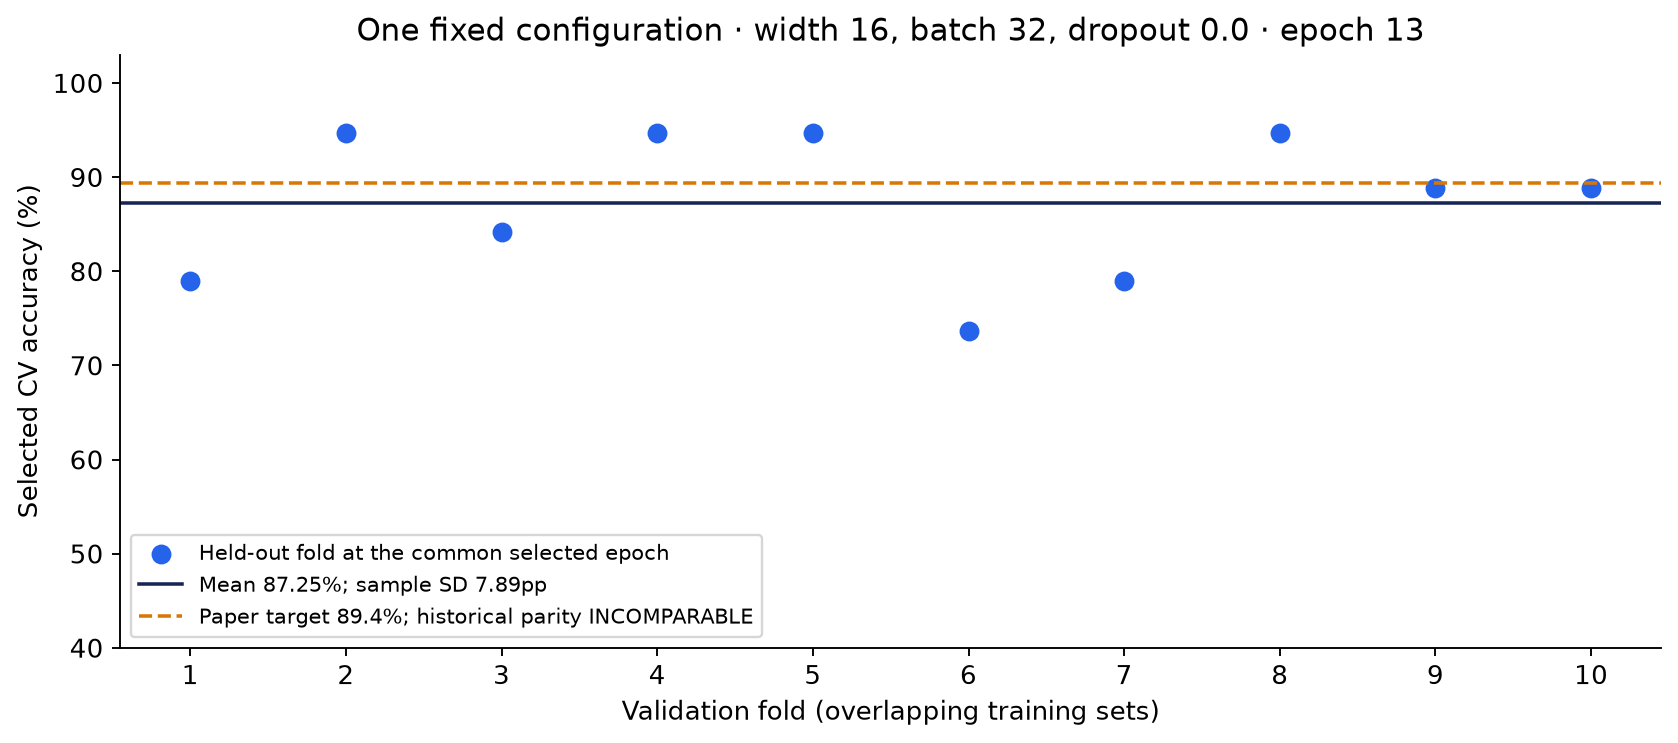</div><figcaption>Fresh MUTAG reconstruction: fold scores at a common selected epoch for each configuration. Historical parity INCOMPARABLE.</figcaption></figure>

> **Scope check.** Modern PyTorch, NumPy and scikit-learn replace the historical runtime. Exact historical fold indices and selected configurations are unavailable. We publish current fold IDs and all curves. The release supplies 350 epochs as a default, not a per-dataset search log. Graph edge ordering and floating-point reductions can change optimization. Only completed candidates are reported above; the full search remains incomplete. Historical numerical parity is **INCOMPARABLE**, even when a score lies near the paper target. Other datasets, GIN-ε training, and a historical-runtime replay are **NOT_RUN**.

Use the [reproduction guide](https://avistian.github.io/relational/labs/l088-reproduction.md) for exact commands, environment pins, source hashes, protocol differences and independent checks. Download [recorded paper-track results](https://avistian.github.io/relational/labs/_paper_l088_results.json) and [verification evidence](https://avistian.github.io/relational/labs/_verify_l088_results.json). Do not silently substitute a 30-epoch teaching run for this search.



## 6 · Lab: which graph readout wins here?

**Held fixed:** the full MUTAG dataset, ten fold assignments, seed, GIN neighbor sum, width 16, batch size 32, no dropout, and a small budget of 30 epochs × 10 updates. **Varied:** only graph readout — sum, mean or max — at every depth. **Measured:** cross-validation accuracy, selecting one common epoch for each readout. This isolates a particular readout intervention under a limited budget, not an intrinsic ranking of architectures.

| Readout | Common epoch | Mean ± sample SD (%) |
|---|---|---|
| sum | 9 | 85.12 ± 7.34 |
| mean | 9 | 84.53 ± 8.22 |
| max | 26 | 86.64 ± 8.37 |

**Max has the highest selected mean in this declared teaching run.** This is descriptive; no significance or universal superiority claim follows.


A max-readout win under this small budget would not contradict the counting argument. The theorem describes which distinctions a representation can preserve; this experiment measures what a particular optimizer learns from a small labeled dataset. Fold differences and model selection both matter.

The published Sum/Mean/Max–MLP rows vary neighborhood aggregation; this lab varies graph readout. They are not the same comparison. A sum readout can exploit graph size, including at the input layer; a size-only baseline would be a useful next diagnostic. A selected CV winner here needs a fresh outer evaluation before a generalization claim.

Open the [student notebook](https://avistian.github.io/relational/labs/0088-graph-classification.ipynb). Its three TODOs are live in the training path:

1. **TODO / CHECK — neighbor sum.** Route each sender to the correct receiver. Check exact sums and gradients; add the center once in the GIN update.
2. **TODO / CHECK — graph readout.** Return one vector per graph for sum, mean and max. Check unequal graph sizes and ensure graphs remain separate.
3. **TODO / CHECK — common epoch.** Select the earliest maximum of the mean validation curve. The counterexample above must pass.

The complete loader, disjoint-union batcher, GIN model, trainer and paper grid are visible in both notebooks. The solution's short execution demonstrates that the learner-facing code runs; the command-line paper track executes the full search. Embedded figures work without repository-relative image paths.

**EXIT artifact.** Save `l088-exit.json` with your three readout results, selected epochs, fold values, and answers to: Why can raw sums collide? Why does a six-cycle collide with two triangles? What makes the selected CV score optimistic? Explain a result that would make you choose mean readout despite its weaker counting ability. Send the artifact and your explanation to the agent for feedback.

Explain the WL bound in your own words; include both graph pairs and the distinction between capacity and generalization.

**Spaced return.** Tomorrow, draw the four-node path/star refinement without looking. In a week, implement grouped sum and recover the common-epoch counterexample from memory. [Lesson 89's planned topic](https://avistian.github.io/relational/reference/graph-classification.html#next) asks how to preserve useful graph computation when the whole graph cannot fit in memory.

Ask the agent about any unclear step; especially challenge the distinction between an expressiveness theorem and a measured predictive advantage. Prepared material does not establish your mastery.


## PROVIDED / TODO / CHECK · complete visible implementation

The functions you implement feed the GIN forward pass and CV selection. No hidden solution imports. Read each docstring; replace each `NotImplementedError`, then run its immediate CHECK.

In [2]:
import hashlib
import io
import json
import urllib.request
import zipfile
from pathlib import Path
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F
from sklearn.model_selection import StratifiedKFold
COMMIT = '9a2ce8ac3e99278307093a464a95caf0fb04b602'
DATA_SHA = '5897dae243f6c773aab54ec99e86551c3b1e8601acef254714073042c632d30e'
ARCHIVE_SHA = '644254dd26f66ad41f47f55aed2d31c20e8884c63629e6bf605e0f82aad76e99'
torch.set_num_threads(1)

PROVIDED · `load_mutag`

In [3]:
def load_mutag(folder='l088-data'):
    """Released 188 graphs, encounter-order label/tag encoding; edge labels unused."""
    folder = Path(folder); folder.mkdir(parents=True, exist_ok=True)
    path = folder / 'MUTAG.txt'
    if not path.exists():
        url = f'https://raw.githubusercontent.com/weihua916/powerful-gnns/{COMMIT}/dataset.zip'
        raw = urllib.request.urlopen(url, timeout=120).read()
        if hashlib.sha256(raw).hexdigest() != ARCHIVE_SHA:
            raise ValueError('Source archive checksum mismatch')
        path.write_bytes(zipfile.ZipFile(io.BytesIO(raw)).read('dataset/MUTAG/MUTAG.txt'))
    raw = path.read_bytes()
    if hashlib.sha256(raw).hexdigest() != DATA_SHA:
        raise ValueError('MUTAG checksum mismatch')
    lines = iter(raw.decode().splitlines()); count = int(next(lines))
    labels, tags, graphs = {}, {}, []
    for graph_id in range(count):
        n, label = map(int, next(lines).split()); labels.setdefault(label, len(labels))
        node_tags, edges = [], set()
        for v in range(n):
            row = list(map(int, next(lines).split())); tag, degree = row[:2]
            assert len(row) == degree + 2
            tags.setdefault(tag, len(tags)); node_tags.append(tags[tag])
            for u in row[2:]:
                assert 0 <= u < n and u != v
                edges.add((min(u,v), max(u,v)))
        pairs = sorted(edges); pairs += [(v,u) for u,v in pairs]
        graphs.append({'id':graph_id,'tags':node_tags,'edges':torch.tensor(pairs).T.contiguous(),
                       'y':labels[label]})
    for g in graphs:
        g['x'] = F.one_hot(torch.tensor(g.pop('tags')), num_classes=len(tags)).float()
    assert len(graphs)==188 and len(tags)==7 and len(labels)==2
    return graphs

PROVIDED · `neighbor_sum`

In [4]:
def neighbor_sum(h, edge_index):
    """Sum incoming messages; edge_index[0] sends to edge_index[1]. No self edges."""
    result = torch.zeros_like(h)
    result.index_add_(0, edge_index[1], h[edge_index[0]])
    return result

In [5]:
h=torch.tensor([[1.,2.],[3.,4.],[5.,6.]],requires_grad=True)
e=torch.tensor([[0,1,1,2],[1,0,2,1]])
y=neighbor_sum(h,e)
torch.testing.assert_close(y,torch.tensor([[3.,4.],[6.,8.],[3.,4.]]))
y.sum().backward();torch.testing.assert_close(h.grad,torch.tensor([[1.,1.],[2.,2.],[1.,1.]]))
print('CHECK passed: incoming sums and gradients')

CHECK passed: incoming sums and gradients


PROVIDED · `graph_readout`

In [6]:
def graph_readout(h, batch, num_graphs, mode='sum'):
    """Reduce node rows independently for each graph. Max is a teaching extension."""
    result = h.new_zeros((num_graphs,h.shape[1]))
    if mode == 'max':
        result.fill_(-torch.inf)
        return result.scatter_reduce(0,batch[:,None].expand_as(h),h,reduce='amax',include_self=True)
    result.index_add_(0,batch,h)
    if mode == 'mean':
        result = result / torch.bincount(batch,minlength=num_graphs)[:,None]
    elif mode != 'sum':
        raise ValueError(mode)
    return result

In [7]:
h=torch.tensor([[1.,0.],[1.,0.],[0.,1.],[2.,3.]])
b=torch.tensor([0,0,0,1])
torch.testing.assert_close(graph_readout(h,b,2),torch.tensor([[2.,1.],[2.,3.]]))
torch.testing.assert_close(graph_readout(h,b,2,'mean'),torch.tensor([[2/3,1/3],[2.,3.]]))
torch.testing.assert_close(graph_readout(h,b,2,'max'),torch.tensor([[1.,1.],[2.,3.]]))
print('CHECK passed: unequal sizes and separate graphs')

CHECK passed: unequal sizes and separate graphs


PROVIDED · `select_epoch`

In [8]:
def select_epoch(fold_curves):
    """One common epoch maximizes equally weighted mean fold accuracy; earliest tie."""
    curves = np.asarray(fold_curves,dtype=float)
    if curves.ndim != 2 or not np.isfinite(curves).all():
        raise ValueError('Expected finite fold-by-epoch curves')
    return int(curves.mean(axis=0).argmax())

In [9]:
assert select_epoch([[.9,.8],[.5,.8]])==1
assert select_epoch([[.8,.8],[.6,.6]])==0
print('CHECK passed: one common epoch, earliest tie')

CHECK passed: one common epoch, earliest tie


PROVIDED · `collate`

In [10]:
def collate(graphs):
    """Disjoint union: offset node IDs, retain one graph ID per node, graph labels."""
    xs,edges,batch,labels=[],[],[],[];offset=0
    for i,g in enumerate(graphs):
        xs.append(g['x']);edges.append(g['edges']+offset)
        batch.append(torch.full((len(g['x']),),i,dtype=torch.long))
        labels.append(g['y']);offset+=len(g['x'])
    return torch.cat(xs),torch.cat(edges,dim=1),torch.cat(batch),torch.tensor(labels)

PROVIDED · `MLP`

In [11]:
class MLP(nn.Module):
    """Two affine layers, internal BatchNorm and ReLU, linear output."""
    def __init__(self,input_dim,hidden_dim):
        super().__init__()
        self.linears=nn.ModuleList([nn.Linear(input_dim,hidden_dim),nn.Linear(hidden_dim,hidden_dim)])
        self.batch_norms=nn.ModuleList([nn.BatchNorm1d(hidden_dim)])
    def forward(self,x):
        return self.linears[1](F.relu(self.batch_norms[0](self.linears[0](x))))

PROVIDED · `GIN`

In [12]:
class GIN(nn.Module):
    """Four message updates plus input readout, matching the release's five layers.

    Each update has its own MLP and outer BatchNorm. Nodes/graphs share these
    weights. Linear prediction heads differ by depth; dropout acts on logits.
    """
    def __init__(self,input_dim=7,hidden_dim=16,classes=2,dropout=0.,learn_eps=False,readout='sum'):
        super().__init__();self.dropout=dropout;self.learn_eps=learn_eps;self.readout=readout
        self.eps=nn.Parameter(torch.zeros(4)) # unused, as in release, for GIN-0
        self.mlps=nn.ModuleList();self.batch_norms=nn.ModuleList()
        for layer in range(4):
            self.mlps.append(MLP(input_dim if layer==0 else hidden_dim,hidden_dim))
            self.batch_norms.append(nn.BatchNorm1d(hidden_dim))
        self.linears_prediction=nn.ModuleList([nn.Linear(input_dim if k==0 else hidden_dim,classes) for k in range(5)])
    def forward(self,packed):
        h,edges,batch,labels=packed;states=[h]
        for k in range(4):
            eps=self.eps[k] if self.learn_eps else 0.
            h=neighbor_sum(h,edges)+(1+eps)*h
            h=F.relu(self.batch_norms[k](self.mlps[k](h)));states.append(h)
        score=0
        for k,h in enumerate(states):
            pooled=graph_readout(h,batch,len(labels),self.readout)
            score=score+F.dropout(self.linears_prediction[k](pooled),self.dropout,training=self.training)
        return score

PROVIDED · `folds_for`

In [13]:
def folds_for(graphs,split_seed=0):
    y=[g['y'] for g in graphs]
    return list(StratifiedKFold(n_splits=10,shuffle=True,random_state=split_seed).split(np.zeros(len(y)),y))

PROVIDED · `evaluate`

In [14]:
@torch.no_grad()
def evaluate(model,graphs):
    model.eval();out=[]
    for start in range(0,len(graphs),64):out.append(model(collate(graphs[start:start+64])))
    logits=torch.cat(out);labels=torch.tensor([g['y'] for g in graphs])
    return float((logits.argmax(1)==labels).float().mean()),logits

PROVIDED · `train_fold`

In [15]:
def train_fold(graphs,fold=0,hidden=16,batch_size=32,dropout=0.,epochs=350,iters=50,
               seed=0,split_seed=0,readout='sum'):
    """Full-size release recipe. An epoch means 50 random subset updates, not a pass.

    PyTorch 1.0 StepLR behavior is explicit: epochs 1..50 use .01, 51..100 .005.
    Validation never changes updates. Selection is performed after all folds.
    """
    torch.set_num_threads(1);torch.manual_seed(seed);np.random.seed(seed)
    train_ids,val_ids=folds_for(graphs,split_seed)[fold]
    train=[graphs[i] for i in train_ids];valid=[graphs[i] for i in val_ids]
    model=GIN(graphs[0]['x'].shape[1],hidden,2,dropout,False,readout)
    optimizer=torch.optim.Adam(model.parameters(),lr=.01)
    curves=[];logits_by_epoch=[]
    for epoch in range(1,epochs+1):
        lr=.01 * .5**((epoch-1)//50)
        for group in optimizer.param_groups:group['lr']=lr
        model.train();loss_sum=0.
        for _ in range(iters):
            ids=np.random.permutation(len(train))[:batch_size]
            packed=collate([train[i] for i in ids]);logits=model(packed)
            loss=F.cross_entropy(logits,packed[3]);optimizer.zero_grad();loss.backward();optimizer.step()
            loss_sum+=float(loss.detach())
        acc,logits=evaluate(model,valid);train_acc,_=evaluate(model,train)
        # Exact integer ratio avoids rounding mean(float32) during model selection.
        acc=float((logits.argmax(1)==torch.tensor([g['y'] for g in valid])).sum())/len(valid)
        curves.append({'epoch':epoch,'lr':lr,'loss':loss_sum/iters,'train_acc':train_acc,'val_acc':acc})
        logits_by_epoch.append(logits.numpy())
    record={'config':{'hidden':hidden,'batch_size':batch_size,'dropout':dropout,'epochs':epochs,
            'iters':iters,'seed':seed,'split_seed':split_seed,'readout':readout},'fold':fold,
            'train_ids':train_ids.tolist(),'val_ids':val_ids.tolist(),'curves':curves}
    return record,np.stack(logits_by_epoch)

PROVIDED · `paper_grid`

In [16]:
def paper_grid():
    return [{'hidden':h,'batch_size':b,'dropout':d} for h in [16,32] for b in [32,128] for d in [0.,.5]]

PROVIDED · `summarize_grid`

In [17]:
def summarize_grid(records):
    """Fail closed on incomplete grid; select one config and one common epoch."""
    candidates=[]
    for config in paper_grid():
        rows=sorted([r for r in records if all(r['config'][k]==v for k,v in config.items())],key=lambda r:r['fold'])
        assert [r['fold'] for r in rows]==list(range(10))
        assert all(r['config']['epochs']==350 and r['config']['iters']==50 and r['config']['readout']=='sum' for r in rows)
        curves=np.array([[c['val_acc'] for c in r['curves']] for r in rows]);epoch=select_epoch(curves)
        values=curves[:,epoch]
        candidates.append({'config':config,'epoch':epoch+1,'mean':float(values.mean()),
            'fold_values':values.tolist(),'population_sd':float(values.std(ddof=0)),
            'sample_sd':float(values.std(ddof=1))})
    winner=max(candidates,key=lambda r:r['mean'])
    return {'target':'Xu et al. 2019 Table 1 MUTAG GIN-0','paper_mean':.894,'paper_sd':.056,
            'status':'FULL_GRID_EXECUTED','historical_parity':'INCOMPARABLE',
            'reason':'Modern runtime/splitter and edge reduction order; historical split IDs and selected config unavailable.',
            'selection':'Maximum mean validation curve, common epoch; first config and earliest epoch break ties. No independent test set.',
            'candidates':candidates,'selected':winner,'fold_runs':len(records),'optimizer_updates':80*350*50}

## RUN · short live forward/training check

All 188 graphs are loaded. Train fold 0 for two epochs × 10 updates with each readout. These fresh numbers are a smoke check, not the 30-epoch/10-fold author comparison and not the paper result.

In [18]:
graphs=load_mutag()
smoke=[]
for mode in ['sum','mean','max']:
    r,_=train_fold(graphs,fold=0,epochs=2,iters=10,readout=mode)
    smoke.append({'readout':mode,'curve':r['curves']})
print(json.dumps(smoke,indent=2))

[
  {
    "readout": "sum",
    "curve": [
      {
        "epoch": 1,
        "lr": 0.01,
        "loss": 1.3341742873191833,
        "train_acc": 0.6982248425483704,
        "val_acc": 0.7368421052631579
      },
      {
        "epoch": 2,
        "lr": 0.01,
        "loss": 0.4943861350417137,
        "train_acc": 0.7928994297981262,
        "val_acc": 0.9473684210526315
      }
    ]
  },
  {
    "readout": "mean",
    "curve": [
      {
        "epoch": 1,
        "lr": 0.01,
        "loss": 0.46666806638240815,
        "train_acc": 0.6627218723297119,
        "val_acc": 0.6842105263157895
      },
      {
        "epoch": 2,
        "lr": 0.01,
        "loss": 0.3430890440940857,
        "train_acc": 0.3964497148990631,
        "val_acc": 0.5263157894736842
      }
    ]
  },
  {
    "readout": "max",
    "curve": [
      {
        "epoch": 1,
        "lr": 0.01,
        "loss": 0.5071616917848587,
        "train_acc": 0.6627218723297119,
        "val_acc": 0.7368421052631579
  

## RUN · reproduce the complete teaching comparison

Set `RUN_TEACHING=True` to obtain ten-fold readout measurements from your own implementation. It uses the declared small budget; it does not reproduce Table 1.

In [19]:
RUN_TEACHING = False
learner_results=[]
if RUN_TEACHING:
    for mode in ['sum','mean','max']:
        records=[train_fold(graphs,fold=f,epochs=30,iters=10,readout=mode)[0] for f in range(10)]
        curves=np.array([[e['val_acc'] for e in r['curves']] for r in records])
        epoch=select_epoch(curves);values=curves[:,epoch]
        learner_results.append({'readout':mode,'selected_epoch':epoch+1,'mean':float(values.mean()),'sample_sd':float(values.std(ddof=1)),'fold_values':values.tolist()})
    print(learner_results)

## FULL REPRODUCTION · MUTAG Table 1 GIN-0

Set `RUN_FULL_PAPER=True` for all 80 trainings. This may take hours on a laptop. This notebook path is sequential and fresh. The repository CLI parallelizes folds and verifies fingerprints before reusing completed runs. No parameter is downscaled here.

In [20]:
RUN_FULL_PAPER = False
if RUN_FULL_PAPER:
    records=[]
    out=Path('l088-paper');out.mkdir(exist_ok=True)
    for ci,config in enumerate(paper_grid()):
        for fold in range(10):
            r,z=train_fold(graphs,fold=fold,**config)
            records.append(r)
            (out/f'config{ci}-fold{fold}.json').write_text(json.dumps(r,indent=2))
            np.savez_compressed(out/f'config{ci}-fold{fold}.npz',logits=z,val_ids=r['val_ids'],labels=[graphs[i]['y'] for i in r['val_ids']])
    result=summarize_grid(records)
    Path('l088-paper-results.json').write_text(json.dumps(result,indent=2))
    print(result['selected'])

## EXIT · submit measurements and explanation

Run the teaching comparison, fill all three explanations, then save this artifact. A smoke output is not a completed EXIT. Compare to the author evidence only after your predictions are written.

In [21]:
explanations={'raw_sum_collision':'','wl_counterexample':'','selection_optimism':''}
exit_artifact={'complete':bool(learner_results) and all(explanations.values()),'readout_results':learner_results,'smoke':smoke,'explanations':explanations}
Path('l088-exit.json').write_text(json.dumps(exit_artifact,indent=2))
print('EXIT complete:',exit_artifact['complete'])

EXIT complete: False
